In [3]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import files
uploaded = files.upload()
columns = ["age","sex","cp","trestbps","chol","fbs","restecg",
           "thalach","exang","oldpeak","slope","ca","thal","target"]
cleveland = pd.read_csv("processed.cleveland.data", names=columns, na_values="?")
hungarian = pd.read_csv("processed.hungarian.data", names=columns, na_values="?")
switzerland = pd.read_csv("processed.switzerland.data", names=columns, na_values="?")
va = pd.read_csv("processed.va.data", names=columns, na_values="?")

Saving processed.cleveland.data to processed.cleveland.data
Saving processed.hungarian.data to processed.hungarian.data
Saving processed.switzerland.data to processed.switzerland.data
Saving processed.va.data to processed.va.data


In [5]:
cleveland["source"] = "cleveland"
hungarian["source"] = "hungarian"
switzerland["source"] = "switzerland"
va["source"] = "va"

print(cleveland.shape)
print(hungarian.shape)
print(switzerland.shape)
print(va.shape)

(303, 15)
(294, 15)
(123, 15)
(200, 15)


In [6]:
combined = pd.concat([cleveland, hungarian, switzerland, va], ignore_index=True)
print(combined.shape)
# This cell combines the individual datasets into a single dataframe 'combined'.

(920, 15)


In [7]:
combined["chol"] = combined["chol"].replace(0, np.nan)
combined["trestbps"] = combined["trestbps"].replace(0, np.nan)
print(combined.isnull().sum())
print(combined.groupby("source").apply(lambda x: x.isnull().sum(), include_groups=False))

age           0
sex           0
cp            0
trestbps     60
chol        202
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
source        0
dtype: int64
             age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  \
source                                                                    
cleveland      0    0   0         0     0    0        0        0      0   
hungarian      0    0   0         1    23    8        1        1      1   
switzerland    0    0   0         2   123   75        1        1      1   
va             0    0   0        57    56    7        0       53     53   

             oldpeak  slope   ca  thal  target  
source                                          
cleveland          0      0    4     2       0  
hungarian          0    190  291   266       0  
switzerland        6     17  118    52       0  
va                56    102  198   166       0  


In [8]:
combined["ca_missing"] = combined["ca"].isnull().astype(int)
combined["thal_missing"] = combined["thal"].isnull().astype(int)
combined["slope_missing"] = combined["slope"].isnull().astype(int)
combined["chol_missing"] = combined["chol"].isnull().astype(int)
print(combined.shape)  # should jump from 15 to 19 columns here

(920, 19)


In [9]:
print(combined.groupby("source")["target"].value_counts(normalize=True).sort_index())

source       target
cleveland    0         0.541254
             1         0.181518
             2         0.118812
             3         0.115512
             4         0.042904
hungarian    0         0.639456
             1         0.360544
switzerland  0         0.065041
             1         0.390244
             2         0.260163
             3         0.243902
             4         0.040650
va           0         0.255000
             1         0.280000
             2         0.205000
             3         0.210000
             4         0.050000
Name: proportion, dtype: float64


In [10]:
# Version 1: Multi-class severity (only hospitals that actually have grades 0-4)
multiclass_df = combined[combined["source"].isin(["cleveland", "switzerland", "va"])].copy()
print("Multi-class dataset:", multiclass_df.shape)
print(multiclass_df["target"].value_counts().sort_index())

# Version 2: Binary (full 920 rows, all 4 hospitals)
binary_df = combined.copy()
binary_df["target_binary"] = (binary_df["target"] > 0).astype(int)
print("\nBinary dataset:", binary_df.shape)
print(binary_df["target_binary"].value_counts())

Multi-class dataset: (626, 19)
target
0    223
1    159
2    109
3    107
4     28
Name: count, dtype: int64

Binary dataset: (920, 20)
target_binary
1    509
0    411
Name: count, dtype: int64


In [11]:
# Version 1: Multi-class severity (only hospitals that actually have grades 0-4)
multiclass_df = combined[combined["source"].isin(["cleveland", "switzerland", "va"])].copy()
print("Multi-class dataset:", multiclass_df.shape)
print(multiclass_df["target"].value_counts().sort_index())

# Version 2: Binary (full 920 rows, all 4 hospitals)
binary_df = combined.copy()
binary_df["target_binary"] = (binary_df["target"] > 0).astype(int)
print("\nBinary dataset:", binary_df.shape)
print(binary_df["target_binary"].value_counts())

Multi-class dataset: (626, 19)
target
0    223
1    159
2    109
3    107
4     28
Name: count, dtype: int64

Binary dataset: (920, 20)
target_binary
1    509
0    411
Name: count, dtype: int64


In [12]:
# Numeric small-gap columns -> median
for col in ["thalach", "trestbps"]:
    combined[col] = combined[col].fillna(combined[col].median())

# Categorical small-gap columns -> mode
for col in ["fbs", "exang", "restecg"]:
    combined[col] = combined[col].fillna(combined[col].mode()[0])

print(combined[["thalach","trestbps","fbs","exang","restecg"]].isnull().sum())

thalach     0
trestbps    0
fbs         0
exang       0
restecg     0
dtype: int64


In [13]:
combined["chol"] = combined.groupby("source")["chol"].transform(
    lambda x: x.fillna(x.median())
)
print(combined["chol"].isnull().sum())

123


In [14]:
combined["slope"] = combined["slope"].fillna(combined["slope"].mode()[0])
print(combined["slope"].isnull().sum())

0


In [15]:
from sklearn.impute import KNNImputer

knn_cols = ["age","sex","cp","trestbps","chol","fbs","restecg",
            "thalach","exang","oldpeak","slope","ca","thal"]

imputer = KNNImputer(n_neighbors=5)
combined[knn_cols] = imputer.fit_transform(combined[knn_cols])

print(combined[["ca","thal"]].isnull().sum())

ca      0
thal    0
dtype: int64


In [16]:
print(combined.isnull().sum())
print(combined.shape)
print([c for c in combined.columns if "missing" in c])

age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
target           0
source           0
ca_missing       0
thal_missing     0
slope_missing    0
chol_missing     0
dtype: int64
(920, 19)
['ca_missing', 'thal_missing', 'slope_missing', 'chol_missing']


In [17]:
# Version 1: Multi-class severity (only hospitals with real 0-4 grades)
multiclass_df = combined[combined["source"].isin(["cleveland", "switzerland", "va"])].copy()

# Version 2: Binary (all 4 hospitals)
binary_df = combined.copy()
binary_df["target_binary"] = (binary_df["target"] > 0).astype(int)

print("Multi-class:", multiclass_df.shape)
print("Binary:", binary_df.shape)
print(multiclass_df["target"].value_counts().sort_index())
print(binary_df["target_binary"].value_counts())

Multi-class: (626, 19)
Binary: (920, 20)
target
0    223
1    159
2    109
3    107
4     28
Name: count, dtype: int64
target_binary
1    509
0    411
Name: count, dtype: int64


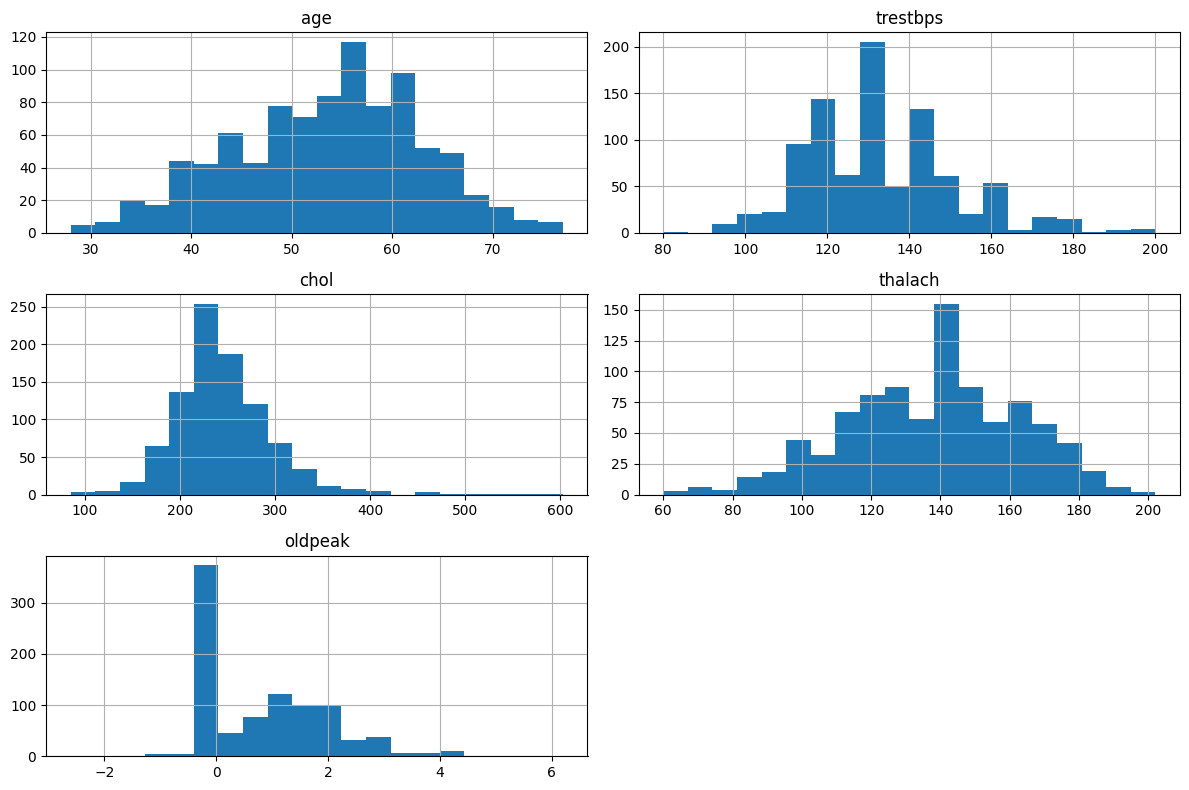

In [19]:
import matplotlib.pyplot as plt

binary_df.hist(column=["age","trestbps","chol","thalach","oldpeak"], figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

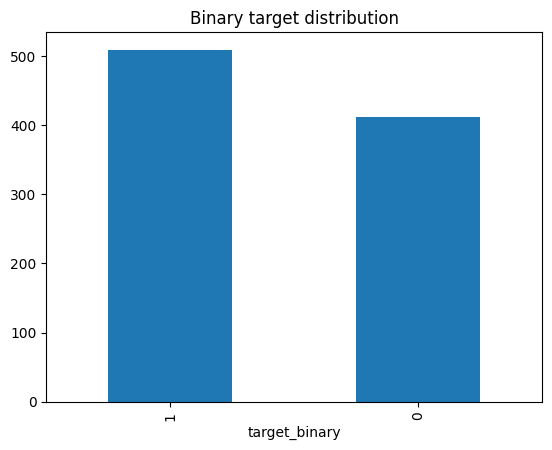

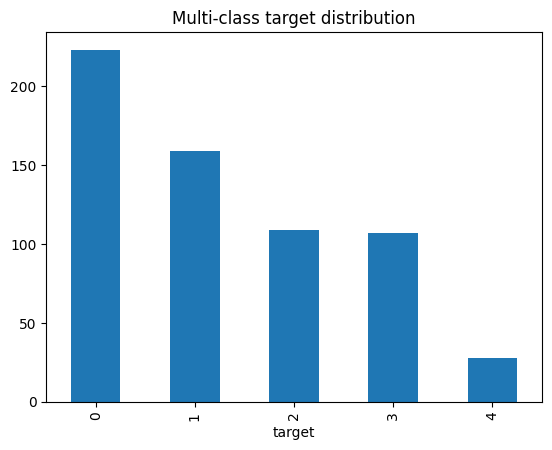

In [20]:
binary_df["target_binary"].value_counts().plot(kind="bar", title="Binary target distribution")
plt.show()

multiclass_df["target"].value_counts().sort_index().plot(kind="bar", title="Multi-class target distribution")
plt.show()

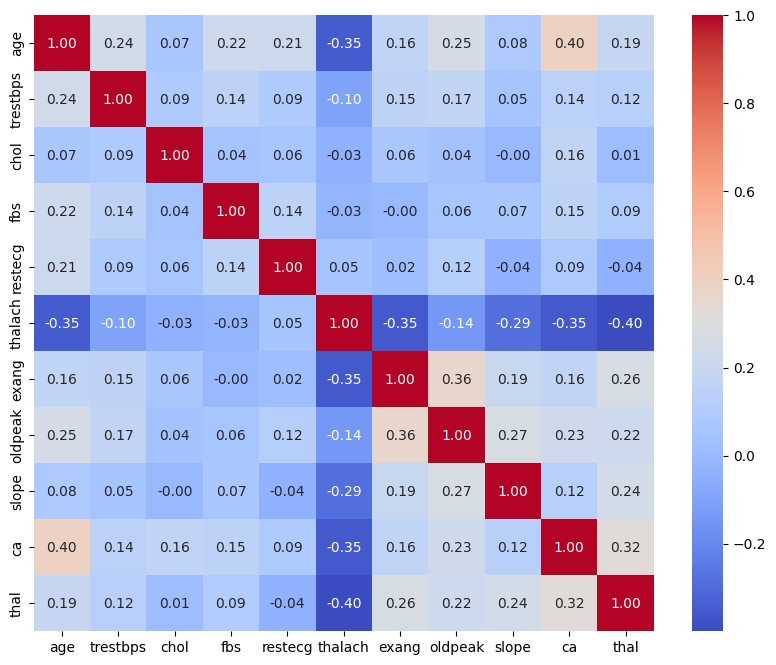

In [21]:
import seaborn as sns

numeric_cols = ["age","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal"]
plt.figure(figsize=(10,8))
sns.heatmap(binary_df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [18]:
multiclass_df.to_csv("multiclass_dataset.csv", index=False)
binary_df.to_csv("binary_dataset.csv", index=False)

from google.colab import files
files.download("multiclass_dataset.csv")
files.download("binary_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>